In [1]:
import pandas as pd
import numpy as np
import datetime as dt

# 1. Load the dataset using your specific folder path!
print("Loading dataset... (This might take 1-2 minutes)")
file_path = r"C:\Users\HP\Downloads\Arnab DS Projects\Customer Segmentation & RFM Analysis for Marketing Campaigns\Datasets\online+retail\Online Retail.xlsx"
df = pd.read_excel(file_path)
print("Dataset loaded successfully!")

# 2. Data Cleaning
# Remove rows without CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders (InvoiceNo starts with 'C') and negative quantities/prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceNo'] = df['InvoiceNo'].astype(str)
df = df[~df['InvoiceNo'].str.startswith('C')]

# 3. Feature Engineering
# Calculate Total Price for each transaction line
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"Cleaned dataset shape: {df.shape}")
df.head() # This will display the first 5 rows of your cleaned data


Loading dataset... (This might take 1-2 minutes)
Dataset loaded successfully!
Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [2]:
# Set a snapshot date (1 day after the latest transaction in the dataset)
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by CustomerID to calculate the RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

# Rename the columns to standard RFM names
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

print("RFM Scores Calculated Successfully!")
rfm.head() # Display the first 5 customers' RFM scores


RFM Scores Calculated Successfully!


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


Calculating optimal clusters... (Graphs will appear shortly!)


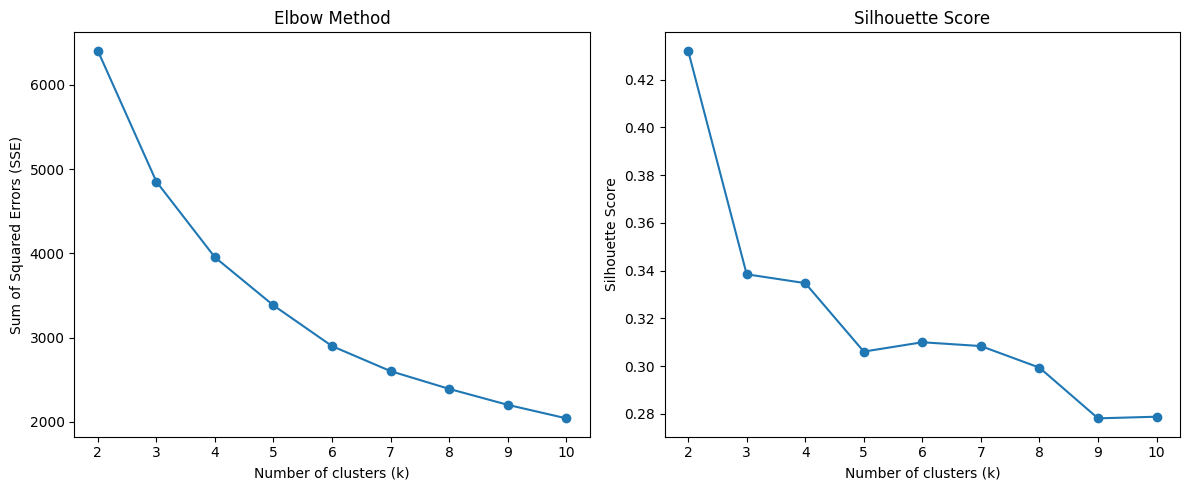


--- Cluster Summary Averages ---
        Recency Frequency Monetary      
           mean      mean     mean count
Cluster                                 
0           7.1      18.2  11882.0   403
1          20.8       1.8    440.8   748
2          29.6       5.9   2391.8   993
3         116.7       2.7   1132.5   971
4         196.5       1.1    260.5  1223

Success! Exported ready-to-use data to: C:\Users\HP\Downloads\Arnab DS Projects\Customer Segmentation & RFM Analysis for Marketing Campaigns\Datasets\online+retail\segmented_customer_data.csv


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Handle Skewness (Log Transformation)
# RFM data is usually very skewed. Log transformation fixes this.
rfm_log = np.log(rfm[['Recency', 'Frequency', 'Monetary']] + 0.1)

# 2. Scaling (Standardization)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

# 3. Determine Optimal Clusters (Elbow Method & Silhouette Score)
sse = {}
silhouette_avg = {}
K = range(2, 11)

print("Calculating optimal clusters... (Graphs will appear shortly!)")
for k in K:
    # n_init=10 prevents future warnings in scikit-learn
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) 
    kmeans.fit(rfm_scaled)
    sse[k] = kmeans.inertia_
    silhouette_avg[k] = silhouette_score(rfm_scaled, kmeans.labels_)

# Plot Elbow Curve and Silhouette Scores
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(sse.keys()), list(sse.values()), marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Sum of Squared Errors (SSE)')

plt.subplot(1, 2, 2)
plt.plot(list(silhouette_avg.keys()), list(silhouette_avg.values()), marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

# 4. Apply K-Means with exactly 5 Clusters (As required by your capstone)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# 5. Profile the Clusters
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'count']
}).round(1)
print("\n--- Cluster Summary Averages ---")
print(cluster_summary)

# 6. Map Clusters to Segment Names 
# (You can adjust these later if the averages don't perfectly align)
segment_map = {
    0: 'Hibernating',
    1: 'Champions',
    2: 'Loyalists',
    3: 'At Risk',
    4: 'New'
}
rfm['Segment'] = rfm['Cluster'].map(segment_map)

# 7. Export for Power BI!
final_df = pd.merge(df, rfm[['CustomerID', 'Segment', 'Recency', 'Frequency', 'Monetary']], on='CustomerID', how='inner')

# Save to the same folder where your original dataset is
file_path_out = r"C:\Users\HP\Downloads\Arnab DS Projects\Customer Segmentation & RFM Analysis for Marketing Campaigns\Datasets\online+retail\segmented_customer_data.csv"
final_df.to_csv(file_path_out, index=False)

print(f"\nSuccess! Exported ready-to-use data to: {file_path_out}")
